# Taller Abandono de producto financiero

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Estructura de los datos

In [2]:
df_raw = pd.read_csv("abandono_producto_financiero.csv", encoding="utf-8")
df_raw.head()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.0000,1,1,1,"101,348.8800",1
1,2,15647311,Hill,608,España,Mujer,41,1,"83,807.8600",1,0,1,"112,542.5800",0
2,3,15619304,Onio,502,Francia,Mujer,42,8,"159,660.8000",3,1,0,"113,931.5700",1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.0000,2,0,0,"93,826.6300",0
4,5,15737888,Mitchell,850,España,Mujer,43,2,"125,510.8200",1,1,1,"79,084.1000",0


In [3]:
print("Columnas:", list(df_raw.columns))
print("Dimensión (filas, columnas):", df_raw.shape)
df_raw.dtypes

Columnas: ['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']
Dimensión (filas, columnas): (10000, 14)


numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64
dtype: object

In [4]:
df_raw.describe()

,numero_fila,id_cliente,puntaje_crediticio,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
count,"10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000","10,000.0000"
mean,"5,000.5000","15,690,940.5694",650.5288,38.9218,5.0128,"76,485.8893",1.5302,0.7055,0.5151,"100,090.2399",0.2037
std,"2,886.8957","71,936.1861",96.6533,10.4878,2.8922,"62,397.4052",0.5817,0.4558,0.4998,"57,510.4928",0.4028
min,1.0000,"15,565,701.0000",350.0000,18.0000,0.0000,0.0000,1.0000,0.0000,0.0000,11.5800,0.0000
25%,"2,500.7500","15,628,528.2500",584.0000,32.0000,3.0000,0.0000,1.0000,0.0000,0.0000,"51,002.1100",0.0000
50%,"5,000.5000","15,690,738.0000",652.0000,37.0000,5.0000,"97,198.5400",1.0000,1.0000,1.0000,"100,193.9150",0.0000
75%,"7,500.2500","15,753,233.7500",718.0000,44.0000,7.0000,"127,644.2400",2.0000,1.0000,1.0000,"149,388.2475",0.0000
max,"10,000.0000","15,815,690.0000",850.0000,92.0000,10.0000,"250,898.0900",4.0000,1.0000,1.0000,"199,992.4800",1.0000


In [5]:
df = df_raw.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

df["pais"] = pd.Categorical(df["pais"], categories=["Francia", "Alemania", "España"])
df["sexo"] = pd.Categorical(df["sexo"], categories=["Mujer", "Hombre"])
df["abandono"] = df["abandono"].astype(int)

print("Dimensión para el modelo:", df.shape)
print("Datos faltantes:", df.isna().sum().sum())
df.dtypes

Dimensión para el modelo: (10000, 11)
Datos faltantes: 0


puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64
dtype: object

**1. ¿Cuántas variables tiene la base cruda? ¿Cuántas quedan para el modelo?**
La base cruda tiene **14 variables** y 10.000 filas. Al eliminar los identificadores (`numero_fila`, `id_cliente`, `apellido`) quedan **11 variables**: 10 explicativas y la respuesta `abandono`.

**2. ¿Cuántas son cuantitativas?**
**6**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` (entero) y `salario_estimado`.

**3. ¿Cuántas son categóricas o binarias (incluyendo abandono)?**
**5**: dos categóricas (`pais`, `sexo`) y tres binarias 0/1 (`tiene_tarjeta`, `miembro_activo` y la respuesta `abandono`).

**4. ¿Qué implica esta mezcla para el logit en Python?**
Las numéricas y las binarias 0/1 entran directo en la fórmula. Las categóricas de texto necesitan dummies: con `C(pais)` y `C(sexo)`, `statsmodels` (vía patsy) crea automáticamente $k-1$ dummies por variable y omite la categoría de referencia (la primera de la lista: Francia y Mujer), lo que evita la trampa de las variables ficticias (colinealidad perfecta con el intercepto). Hacer las dummies a mano obliga a crear y excluir columnas manualmente, con riesgo de error; con `C(·)` y los niveles fijados como `category`, las referencias quedan controladas y los coeficientes se leen como "diferencia frente a Francia / frente a Mujer".

## 2. Descriptivo univariado

In [6]:
conteo = df["abandono"].value_counts().sort_index()
prop = df["abandono"].value_counts(normalize=True).sort_index()
tabla_y = pd.DataFrame({"conteo": conteo, "proporcion": prop})
tabla_y

,conteo,proporcion
abandono,,
0,7963,0.7963
1,2037,0.2037


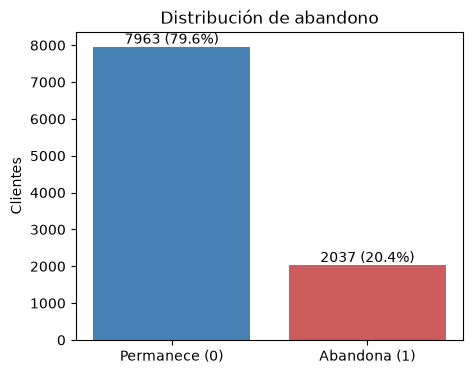

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Permanece (0)", "Abandona (1)"], conteo.values, color=["steelblue", "indianred"])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 80, f"{v} ({prop.values[i]:.1%})", ha="center")
ax.set_ylabel("Clientes")
ax.set_title("Distribución de abandono")
plt.show()

In [8]:
num_vars = ["edad", "puntaje_crediticio", "saldo", "salario_estimado"]
df[num_vars].describe()

,edad,puntaje_crediticio,saldo,salario_estimado
count,"10,000.0000","10,000.0000","10,000.0000","10,000.0000"
mean,38.9218,650.5288,"76,485.8893","100,090.2399"
std,10.4878,96.6533,"62,397.4052","57,510.4928"
min,18.0000,350.0000,0.0000,11.5800
25%,32.0000,584.0000,0.0000,"51,002.1100"
50%,37.0000,652.0000,"97,198.5400","100,193.9150"
75%,44.0000,718.0000,"127,644.2400","149,388.2475"
max,92.0000,850.0000,"250,898.0900","199,992.4800"


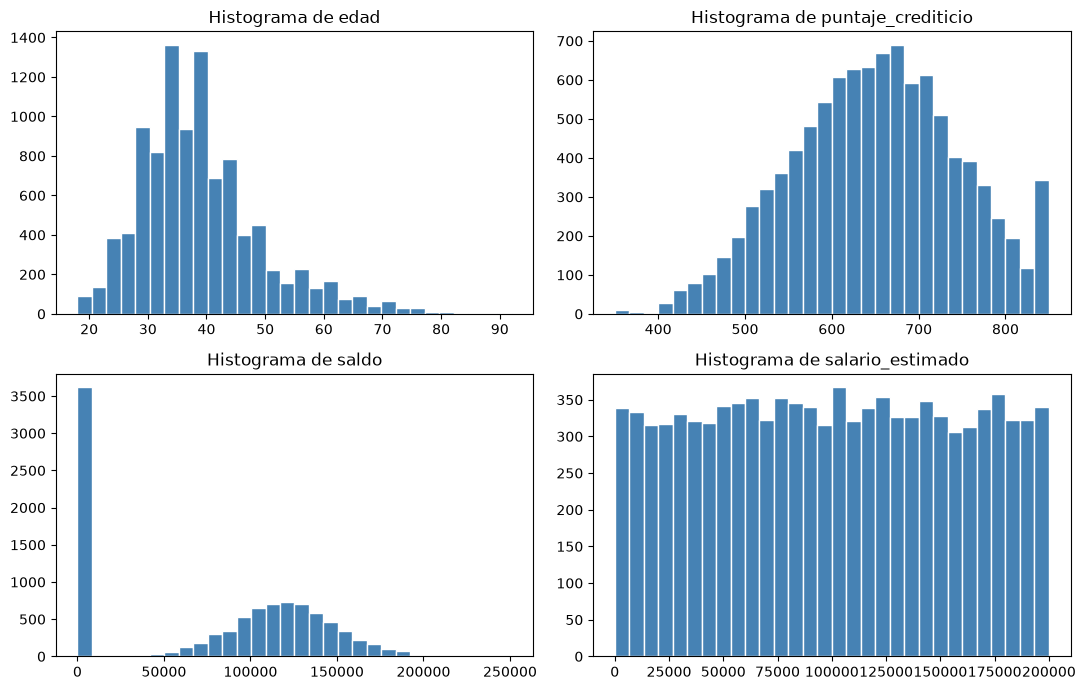

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, v in zip(axes.ravel(), num_vars):
    ax.hist(df[v], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"Histograma de {v}")
plt.tight_layout()
plt.show()

In [10]:
for v in ["pais", "sexo", "numero_productos", "miembro_activo"]:
    t = pd.DataFrame({"conteo": df[v].value_counts().sort_index(),
                      "proporcion": df[v].value_counts(normalize=True).sort_index()})
    print(f"\n--- {v} ---")
    print(t)


--- pais ---
          conteo  proporcion
pais                        
Francia     5014      0.5014
Alemania    2509      0.2509
España      2477      0.2477

--- sexo ---
        conteo  proporcion
sexo                      
Mujer     4543      0.4543
Hombre    5457      0.5457

--- numero_productos ---
                  conteo  proporcion
numero_productos                    
1                   5084      0.5084
2                   4590      0.4590
3                    266      0.0266
4                     60      0.0060

--- miembro_activo ---
                conteo  proporcion
miembro_activo                    
0                 4849      0.4849
1                 5151      0.5151


**5. ¿Qué porcentaje de la base abandonó? ¿Por qué un clasificador que siempre diga «permanece» ya parece bueno si uno solo mira la accuracy?**
Abandonó el **20,37 %** de los clientes (2.037 de 10.000); el 79,63 % permanece. Las clases están desbalanceadas: un clasificador trivial que siempre prediga «permanece» acierta en el 79,63 % de los casos, así que su exactitud ya es cercana al 80 % sin haber aprendido nada. Pero su sensibilidad es 0: no detecta a ninguno de los clientes que se van, que son justamente los que le interesan al área de retención. Por eso la exactitud debe leerse junto con la sensibilidad y la especificidad.

Otros rasgos del univariado: el saldo tiene una gran masa en 0 (≈36 % de los clientes), la edad es sesgada a la derecha (mediana 37, rango 18–92), Francia concentra cerca de la mitad de la base y casi todos los clientes tienen 1 o 2 productos.

## 3. Bivariado con la respuesta

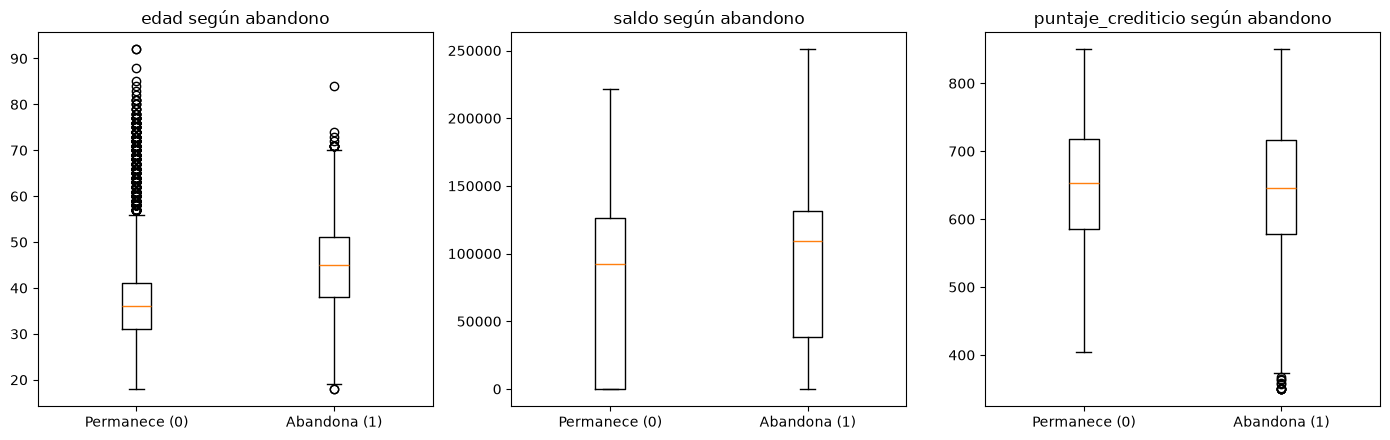

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, v in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    datos = [df.loc[df["abandono"] == 0, v], df.loc[df["abandono"] == 1, v]]
    ax.boxplot(datos, tick_labels=["Permanece (0)", "Abandona (1)"])
    ax.set_title(f"{v} según abandono")
plt.tight_layout()
plt.show()

In [12]:
df.groupby("abandono")[["edad", "saldo", "puntaje_crediticio"]].agg(["median", "mean"])

edad                saldo             puntaje_crediticio         
          median    mean       median        mean             median     mean
abandono                                                                     
0        36.0000 37.4084  92,072.6800 72,745.2968           653.0000 651.8532
1        45.0000 44.8380 109,349.2900 91,108.5393           646.0000 645.3515

In [13]:
resultados_chi = []
for v in ["miembro_activo", "numero_productos", "pais"]:
    tabla = pd.crosstab(df[v], df["abandono"])
    tasa = pd.crosstab(df[v], df["abandono"], normalize="index")
    chi2, p, gl, _ = chi2_contingency(tabla)
    resultados_chi.append({"variable": v, "chi2": chi2, "gl": gl, "p_valor": p})
    print(f"\n===== {v} =====")
    print(tabla)
    print("Tasa por fila:")
    print(tasa.round(3))
    print(f"Ji-cuadrado = {chi2:.2f}, gl = {gl}, p = {p:.3g}")

pd.DataFrame(resultados_chi)


===== miembro_activo =====
abandono           0     1
miembro_activo            
0               3547  1302
1               4416   735
Tasa por fila:
abandono            0      1
miembro_activo              
0              0.7310 0.2690
1              0.8570 0.1430
Ji-cuadrado = 242.99, gl = 1, p = 8.79e-55

===== numero_productos =====
abandono             0     1
numero_productos            
1                 3675  1409
2                 4242   348
3                   46   220
4                    0    60
Tasa por fila:
abandono              0      1
numero_productos              
1                0.7230 0.2770
2                0.9240 0.0760
3                0.1730 0.8270
4                0.0000 1.0000
Ji-cuadrado = 1503.63, gl = 3, p = 0

===== pais =====
abandono     0    1
pais               
Francia   4204  810
Alemania  1695  814
España    2064  413
Tasa por fila:
abandono      0      1
pais                  
Francia  0.8380 0.1620
Alemania 0.6760 0.3240
España   0.8330 0.1670


,variable,chi2,gl,p_valor
0,miembro_activo,242.9853,1,0.0000
1,numero_productos,"1,503.6294",3,0.0000
2,pais,301.2553,2,0.0000


**6. Distribución de edad entre quien abandona y quien permanece.**
Es la diferencia más visible de los boxplots. Quienes abandonan son claramente mayores: **mediana de 45 años** frente a **36 años** en quienes permanecen (medias 44,8 vs 37,4). La caja de los que abandonan está desplazada hacia arriba, y en el grupo que permanece las edades altas aparecen como atípicos. La edad se asocia con más abandono.

**7. Saldo y puntaje crediticio entre los dos grupos.**
*Saldo:* quienes abandonan tienen mayor saldo (mediana ≈ 109.349 frente a ≈ 92.073). Parte de la diferencia viene de la masa de clientes con saldo 0, que se concentra en quienes permanecen. Se van clientes con dinero en la cuenta, lo que hace más costosa la pérdida.
*Puntaje crediticio:* prácticamente no hay diferencia (mediana 646 vs 653; medias 645 vs 652); las cajas casi se superponen. A simple vista no discrimina entre grupos.

**8. ¿Los clientes activos presentan menor abandono?**
Sí. Entre los inactivos abandona el **26,9 %**; entre los activos, el **14,3 %** (casi la mitad). El ji-cuadrado (≈ 243, gl = 1, p ≈ 9×10⁻⁵⁵) rechaza la independencia: estar activo se asocia con menos abandono.

**9. ¿Más productos se asocia siempre con menos abandono?**
**No.** La relación no es monótona: con 1 producto abandona el 27,7 %, con 2 baja al **7,6 %**, pero con 3 sube al **82,7 %** y con 4 abandona el **100 %** (grupos pequeños). El ji-cuadrado es el más alto (≈ 1.504, gl = 3, p ≈ 0). Dos productos es el "punto dulce"; más allá aparece un grupo de altísimo riesgo. Esto importa para el logit: con `numero_productos` como continua, un solo coeficiente no captura esta forma en U.

**10. ¿Qué variable parece tener mayor relación con el abandono?**
Entre las categóricas, **`numero_productos`** tiene la asociación más fuerte (χ² ≈ 1.504, muy por encima de `pais` ≈ 301 y `miembro_activo` ≈ 243), con tasas de abandono que van del 7,6 % al 100 %. Entre las continuas, **`edad`** muestra la separación más clara: 9 años de diferencia en la mediana, frente a diferencias mínimas en puntaje. En conjunto, `numero_productos` y `edad` son las de mayor relación; les siguen `pais` (Alemania 32,4 % frente a ~16 % en Francia y España) y `miembro_activo`.